# Superstore Sales Analysis
## End-to-End Retail Data Analysis using Python

**Author:** Your Name Here
**Dataset:** Superstore Sales Dataset (9,800 rows, 18 columns)
**Tools:** Python, Pandas, Matplotlib, Google Colab

---

## Project Overview
This notebook performs a full end-to-end analysis of a US retail
superstore dataset covering sales transactions across multiple years,
regions, product categories, and customer segments.

## Key Questions Answered
- Which regions and categories drive the most revenue?
- What are the seasonal sales patterns across the year?
- Which products and customers generate the highest value?
- How has sales performance changed year over year?

## Notebook Structure
- **Section 1** — Data Loading & Exploration
- **Section 2** — Data Cleaning
- **Section 3** — Sales Trend Analysis
- **Section 4** — Regional & Segment Analysis
- **Section 5** — Seasonal & Customer Analysis

## Section 1 — Data Loading & Exploration
Loading the raw dataset and performing an initial exploration
to understand its structure, columns, and data quality.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# Load the dataset (adjust filename if yours is different)
# The encoding='latin-1' is important — this file has special characters that break with the default UTF-8 encoding. Always include it.
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TrainDataset.csv', encoding='latin-1')

# Quick check
print("Shape:", df.shape)
print("First few rows:")
df.head(3)

Shape: (9800, 18)
First few rows:


,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


**Exploring the Superstore dataset**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded sucessfully")

Libraries loaded sucessfully


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TrainDataset.csv', encoding='latin-1')
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9800
Columns: 18


In [5]:
# Sees the first 5 lines
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
# Sees the last 5 lines
df.tail()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
print("Column names:")
print(df.columns.tolist())

print("\nData tyoes:")
print(df.dtypes)

Column names:
['ï»¿Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data tyoes:
ï»¿Row ID          int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [8]:
# Check for missing values
print("Missing vakues per columns: ")
missing = df.isnull().sum()
print(missing[missing>= 0]) # show all columns

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage missing: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

Missing vakues per columns: 
ï»¿Row ID         0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Total missing values: 11
Percentage missing: 0.01%


In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Also check duplicate Order IDs (expected - one order can have many products)
dup_orders = df['Order ID'].duplicated().sum()
print(f"Duplicate Order IDs: {dup_orders} (normal - multiple products per order)")

Duplicate rows: 0
Duplicate Order IDs: 4878 (normal - multiple products per order)


In [10]:
# Basic Statistics for Sales
print("Sales column statistics:")
print(df['Sales'].describe().round(2))

Sales column statistics:
count     9800.00
mean       230.77
std        626.65
min          0.44
25%         17.25
50%         54.49
75%        210.60
max      22638.48
Name: Sales, dtype: float64


In [11]:
# Explore categorical columns
print("Unique values per categorical column:\n")

cat_cols = ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']

for col in cat_cols:
    print(f"{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().to_string())
    print()

Unique values per categorical column:

Ship Mode (4 unique):
Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538

Segment (3 unique):
Segment
Consumer       5101
Corporate      2953
Home Office    1746

Country (1 unique):
Country
United States    9800

Region (4 unique):
Region
West       3140
East       2785
Central    2277
South      1598

Category (3 unique):
Category
Office Supplies    5909
Furniture          2078
Technology         1813

Sub-Category (17 unique):
Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66



In [12]:
# Sales by category (first insight)
category_sales = df.groupby('Category')['Sales'].agg(['sum', 'mean', 'count']).round(2)
category_sales.columns = ['Total Sales', 'Average Sale', 'Number of Orders']
category_sales = category_sales.sort_values('Total Sales', ascending=False)

print("Sales by Category:")
print(category_sales)

Sales by Category:
                 Total Sales  Average Sale  Number of Orders
Category                                                    
Technology         827455.87        456.40              1813
Furniture          728658.58        350.65              2078
Office Supplies    705422.33        119.38              5909


In [13]:
# Sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2)

print("Total Sales by Region:")
print(region_sales)

Total Sales by Region:
Region
West       710219.68
East       669518.73
Central    492646.91
South      389151.46
Name: Sales, dtype: float64


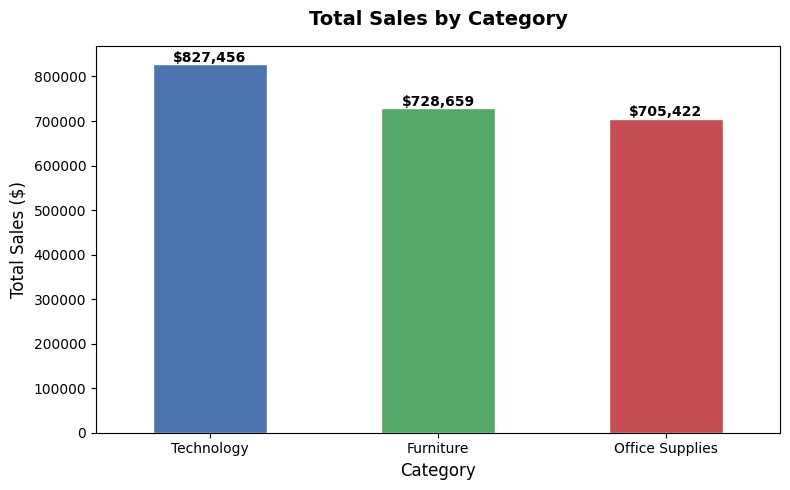

Chart saved!


In [14]:
# 1st chart sales by category
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']
category_sales['Total Sales'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add value labels on top of bars
for i, v in enumerate(category_sales['Total Sales']):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

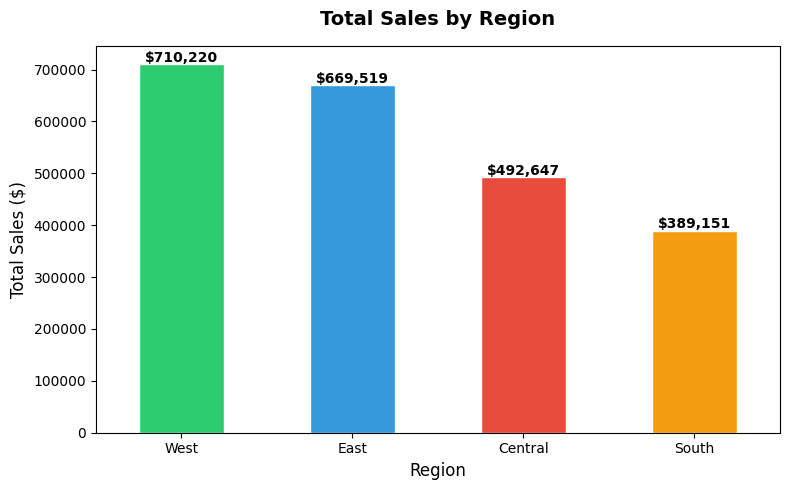

Chart saved!


In [15]:
# 2nd chart sales by region
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
region_sales.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(region_sales):
    ax.text(i, v + 5000, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [16]:
# Summary of findings
print("=" * 50)
print("EXPLORATION SUMMARY")
print("=" * 50)
print(f"\nDataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()} (only in Postal Code)")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nTop category by sales: {category_sales['Total Sales'].idxmax()}")
print(f"Top region by sales:   {region_sales.idxmax()}")
print(f"\nAverage sale value: ${df['Sales'].mean():,.2f}")
print(f"Highest single sale: ${df['Sales'].max():,.2f}")
print(f"Lowest single sale:  ${df['Sales'].min():,.2f}")

EXPLORATION SUMMARY

Dataset: 9800 rows, 18 columns
Missing values: 11 (only in Postal Code)
Duplicate rows: 0

Top category by sales: Technology
Top region by sales:   West

Average sale value: $230.77
Highest single sale: $22,638.48
Lowest single sale:  $0.44


**Cleaning and fixing the data**

## Section 2 — Data Cleaning
Fixing date formats, handling missing values, removing duplicates,
and engineering new features like Order Year, Month, Quarter,
and Shipping Days.

In [17]:
# same as before
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load your file (use whichever path worked for you in Day 2)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TrainDataset.csv', encoding='latin-1')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Dataset loaded: 9800 rows, 18 columns


,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


In [18]:
# Take a screen shot before cleaning always know how the data looked before
print("=== BEFORE CLEANING ===")
print(f"Rows:            {df.shape[0]}")
print(f"Columns:         {df.shape[1]}")
print(f"Missing values:  {df.isnull().sum().sum()}")
print(f"Duplicate rows:  {df.duplicated().sum()}")
print(f"\nData types:")
print(df.dtypes)

=== BEFORE CLEANING ===
Rows:            9800
Columns:         18
Missing values:  11
Duplicate rows:  0

Data types:
ï»¿Row ID          int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [19]:
# dataset has mixed date formats in Ship Date — some rows say 2017-11-11 and
#others say 16/06/2017. This breaks any time-based analysis.

# Fix Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'],
                                   dayfirst=True,
                                   infer_datetime_format=True)

# Fix Ship Date (has the mixed format problem)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],
                                  dayfirst=True,
                                  infer_datetime_format=True)

# Confirm they're now proper datetime type
print("Date column types after fixing:")
print(df[['Order Date', 'Ship Date']].dtypes)
print("\nSample dates:")
print(df[['Order Date', 'Ship Date']].head(5))

Date column types after fixing:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Sample dates:
  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [20]:
# Now that dates are fixed, pull out the useful pieces you'll need for trend analysis.

# Extract from Order Date
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')  # Jan, Feb, Mar...
df['Order Quarter'] = df['Order Date'].dt.quarter

# Calculate how long shipping took (in days)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("New columns added:")
print(df[['Order Date', 'Order Year', 'Order Month',
          'Order Quarter', 'Shipping Days']].head(8))

print(f"\nShipping days range: {df['Shipping Days'].min()} to {df['Shipping Days'].max()} days")
print(f"Average shipping time: {df['Shipping Days'].mean():.1f} days")

New columns added:
  Order Date  Order Year  Order Month  Order Quarter  Shipping Days
0 2017-11-08        2017           11              4              3
1 2017-11-08        2017           11              4              3
2 2017-06-12        2017            6              2              4
3 2016-10-11        2016           10              4              7
4 2016-10-11        2016           10              4              7
5 2015-06-09        2015            6              2              5
6 2015-06-09        2015            6              2              5
7 2015-06-09        2015            6              2              5

Shipping days range: 0 to 7 days
Average shipping time: 4.0 days


In [21]:
# Handling the missing values
print("Missing values BEFORE handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Postal Code: fill missing with 0 (we won't use it for analysis)
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

# Verify all missing values are gone
print("\nMissing values AFTER handling:")
remaining = df.isnull().sum().sum()
print(f"Total missing values: {remaining}")

if remaining == 0:
    print("All missing values handled!")

Missing values BEFORE handling:
Postal Code    11
dtype: int64

Missing values AFTER handling:
Total missing values: 0
All missing values handled!


In [22]:
# Checking and removing any duplicate values
print(f"Duplicate rows before: {df.duplicated().sum()}")

# Remove any duplicate rows (if they exist)
df = df.drop_duplicates()

print(f"Duplicate rows after:  {df.duplicated().sum()}")
print(f"Rows remaining:        {df.shape[0]}")

Duplicate rows before: 0
Duplicate rows after:  0
Rows remaining:        9800


In [23]:
# Cleaning the column names
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Print cleaned column names
print("Clean column names:")
for col in df.columns:
    print(f"  '{col}'")

Clean column names:
  'ï»¿Row ID'
  'Order ID'
  'Order Date'
  'Ship Date'
  'Ship Mode'
  'Customer ID'
  'Customer Name'
  'Segment'
  'Country'
  'City'
  'State'
  'Postal Code'
  'Region'
  'Product ID'
  'Category'
  'Sub-Category'
  'Product Name'
  'Sales'
  'Order Year'
  'Order Month'
  'Order Month Name'
  'Order Quarter'
  'Shipping Days'


In [24]:
# Validating the sales columns
print("Sales column check:")
print(f"  Min value:      ${df['Sales'].min():.2f}")
print(f"  Max value:      ${df['Sales'].max():,.2f}")
print(f"  Negative sales: {(df['Sales'] < 0).sum()}")
print(f"  Zero sales:     {(df['Sales'] == 0).sum()}")
print(f"  Mean sale:      ${df['Sales'].mean():.2f}")

# Flag high-value outliers (sales over $5,000) — not removing, just noting
outliers = df[df['Sales'] > 5000]
print(f"\nHigh-value orders (>$5,000): {len(outliers)} rows")
print(outliers[['Order ID', 'Product Name', 'Sales']].head(5))

Sales column check:
  Min value:      $0.44
  Max value:      $22,638.48
  Negative sales: 0
  Zero sales:     0
  Mean sale:      $230.77

High-value orders (>$5,000): 19 rows
            Order ID                                       Product Name  \
165   CA-2015-139892          Lexmark MX611dhe Monochrome Laser Printer   
509   CA-2016-145352  Fellowes PB500 Electric Punch Plastic Comb Bin...   
683   US-2018-168116          Cubify CubeX 3D Printer Triple Head Print   
2505  CA-2015-143917        High Speed Automatic Electric Letter Opener   
2623  CA-2018-127180              Canon imageCLASS 2200 Advanced Copier   

          Sales  
165    8159.952  
509    6354.950  
683    7999.980  
2505   8187.650  
2623  11199.968  


In [25]:
# Verify categorical columns have clean values
print("Checking for unexpected values in key columns:\n")

expected = {
    'Segment':  ['Consumer', 'Corporate', 'Home Office'],
    'Region':   ['West', 'East', 'Central', 'South'],
    'Category': ['Technology', 'Furniture', 'Office Supplies']
}

for col, valid in expected.items():
    actual = df[col].unique().tolist()
    unexpected = [v for v in actual if v not in valid]
    status = "Clean" if not unexpected else f"Unexpected: {unexpected}"
    print(f"  {col}: {status}")
    print(f"    Values found: {actual}\n")

Checking for unexpected values in key columns:

  Segment: Clean
    Values found: ['Consumer', 'Corporate', 'Home Office']

  Region: Clean
    Values found: ['South', 'West', 'Central', 'East']

  Category: Clean
    Values found: ['Furniture', 'Office Supplies', 'Technology']



In [26]:
# Save the cleaned dataset to Google Drive
cleaned_path = '/content/drive/MyDrive/Colab Notebooks/TrainDataset_Cleaned.csv'
df.to_csv(cleaned_path, index=False)

print(f"Cleaned file saved!")
print(f"Location: {cleaned_path}")
print(f"\nFinal shape: {df.shape[0]} rows, {df.shape[1]} columns")

Cleaned file saved!
Location: /content/drive/MyDrive/Colab Notebooks/TrainDataset_Cleaned.csv

Final shape: 9800 rows, 23 columns


In [27]:
# Before vs After Summary
print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)

print(f"\nOriginal columns:    18")
print(f"New columns added:   {df.shape[1] - 18} (year, month, quarter, shipping days)")
print(f"Final columns:       {df.shape[1]}")
print(f"\nDate columns fixed:  Order Date, Ship Date")
print(f"Missing values:      All resolved (Postal Code filled)")
print(f"Duplicate rows:      {df.duplicated().sum()} remaining")
print(f"Negative sales:      {(df['Sales'] < 0).sum()}")
print(f"\nDate range in data:")
print(f"  Earliest order: {df['Order Date'].min().strftime('%d %b %Y')}")
print(f"  Latest order:   {df['Order Date'].max().strftime('%d %b %Y')}")
print(f"  Years covered:  {sorted(df['Order Year'].unique().tolist())}")


CLEANING SUMMARY

Original columns:    18
New columns added:   5 (year, month, quarter, shipping days)
Final columns:       23

Date columns fixed:  Order Date, Ship Date
Missing values:      All resolved (Postal Code filled)
Duplicate rows:      0 remaining
Negative sales:      0

Date range in data:
  Earliest order: 03 Jan 2015
  Latest order:   30 Dec 2018
  Years covered:  [2015, 2016, 2017, 2018]


## Section 3 — Sales Trend Analysis
Analysing monthly and yearly sales trends, identifying top products,
sub-categories, and understanding revenue distribution.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Always load from the CLEANED file from Day 3
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TrainDataset_Cleaned.csv',
                 parse_dates=['Order Date', 'Ship Date'])

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns available: {df.columns.tolist()}")

Loaded: 9800 rows, 23 columns
Columns available: ['ï»¿Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Shipping Days']


Monthly Sales Trend

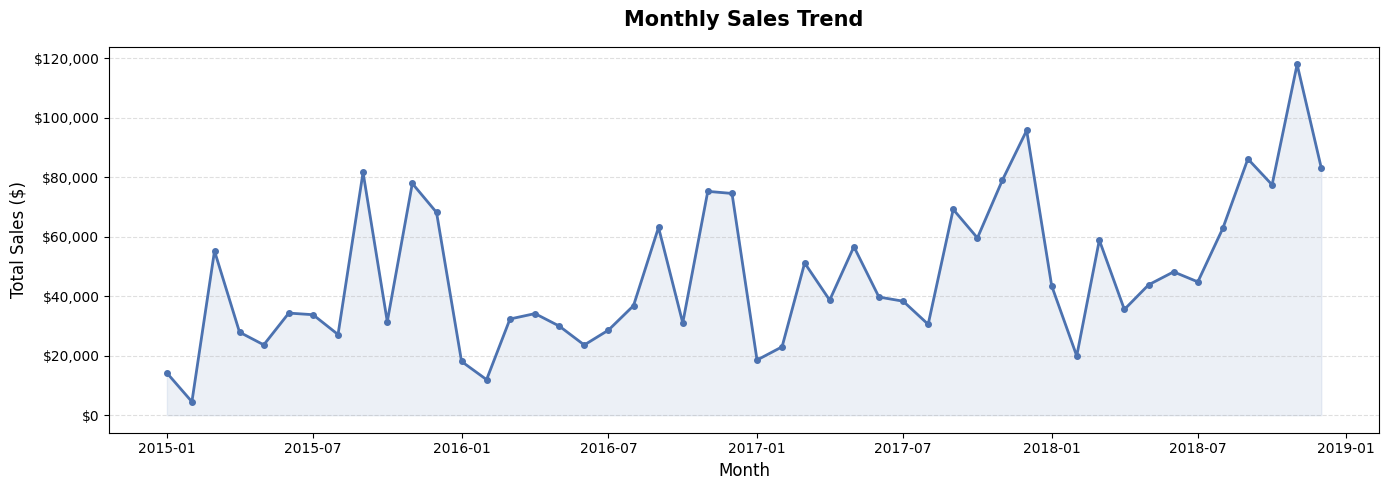

Chart saved!


In [29]:
# Group sales by Year and Month
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year':'year','Order Month':'month'}))
monthly_sales = monthly_sales.sort_values('Date')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_sales['Date'], monthly_sales['Sales'],
        color='#4C72B0', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_sales['Date'], monthly_sales['Sales'],
                alpha=0.1, color='#4C72B0')

ax.set_title('Monthly Sales Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Yearly Sales Comparision

In [30]:
yearly_sales = df.groupby('Order Year')['Sales'].agg(['sum','mean','count']).round(2)
yearly_sales.columns = ['Total Sales', 'Avg Order Value', 'Number of Orders']

print("Sales by Year:")
print(yearly_sales)

# Year-over-year growth
years = yearly_sales.index.tolist()
for i in range(1, len(years)):
    prev = yearly_sales.loc[years[i-1], 'Total Sales']
    curr = yearly_sales.loc[years[i],   'Total Sales']
    growth = ((curr - prev) / prev) * 100
    print(f"\n{years[i-1]} → {years[i]} growth: {growth:+.1f}%")

Sales by Year:
            Total Sales  Avg Order Value  Number of Orders
Order Year                                                
2015          479856.21           245.70              1953
2016          459436.01           223.57              2055
2017          600192.55           236.86              2534
2018          722052.02           221.62              3258

2015 → 2016 growth: -4.3%

2016 → 2017 growth: +30.6%

2017 → 2018 growth: +20.3%


Yearly sales bar chart

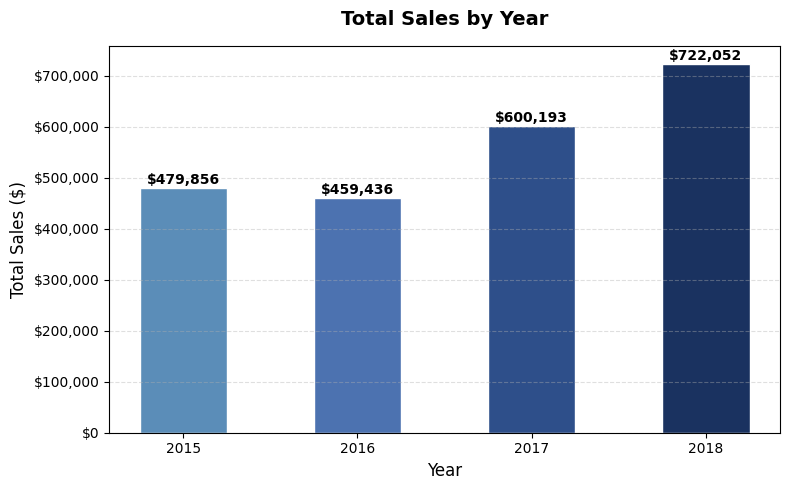

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#5B8DB8', '#4C72B0', '#2E4F8A', '#1A3260'][:len(yearly_sales)]
bars = ax.bar(yearly_sales.index.astype(str),
              yearly_sales['Total Sales'],
              color=colors[:len(yearly_sales)],
              edgecolor='white', width=0.5)

ax.set_title('Total Sales by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 8000,
            f'${h:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('yearly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

Seasonal Patterns (Sales by month names)

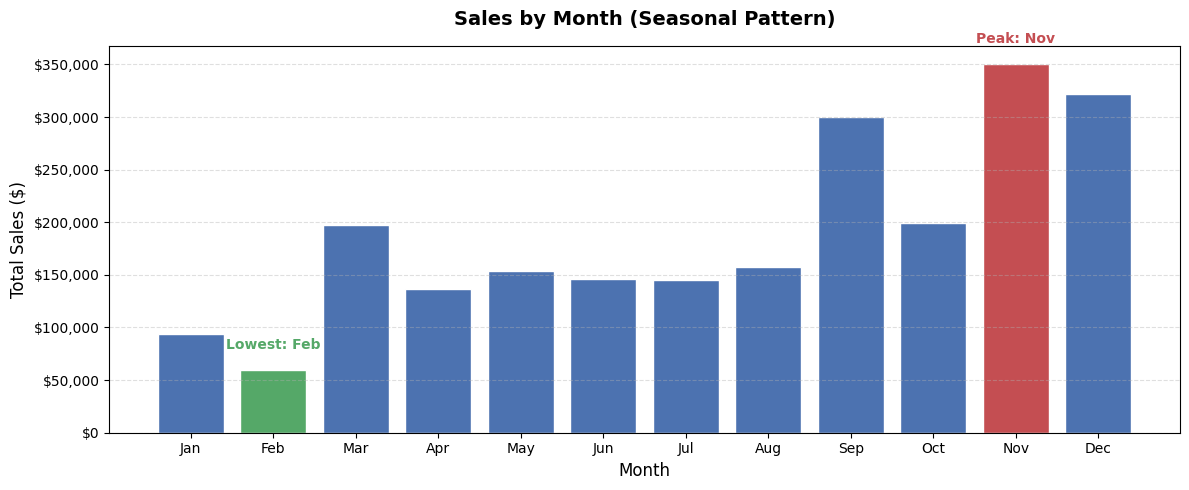

Peak sales month:   Nov ($350,162)
Lowest sales month: Feb ($59,371)


In [32]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = df.groupby('Order Month Name')['Sales'].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['#C44E52' if v == seasonal.max()
              else '#55A868' if v == seasonal.min()
              else '#4C72B0' for v in seasonal]

bars = ax.bar(seasonal.index, seasonal.values,
              color=bar_colors, edgecolor='white')

ax.set_title('Sales by Month (Seasonal Pattern)', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate peak and lowest months
peak_month   = seasonal.idxmax()
low_month    = seasonal.idxmin()
ax.annotate(f'Peak: {peak_month}',
            xy=(list(seasonal.index).index(peak_month), seasonal.max()),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=10, color='#C44E52', fontweight='bold')
ax.annotate(f'Lowest: {low_month}',
            xy=(list(seasonal.index).index(low_month), seasonal.min()),
            xytext=(0, 15), textcoords='offset points',
            ha='center', fontsize=10, color='#55A868', fontweight='bold')

plt.tight_layout()
plt.savefig('seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak sales month:   {peak_month} (${seasonal.max():,.0f})")
print(f"Lowest sales month: {low_month} (${seasonal.min():,.0f})")

Sales by Quater

Sales by Quarter and Year:
                   Q1         Q2         Q3         Q4
Order Year                                            
2015         73931.40   85874.09  142522.61  177528.11
2016         62357.69   87713.37  128560.21  180804.74
2017         92686.36  135061.16  138056.37  234388.65
2018        122260.88  127558.62  193815.84  278416.68


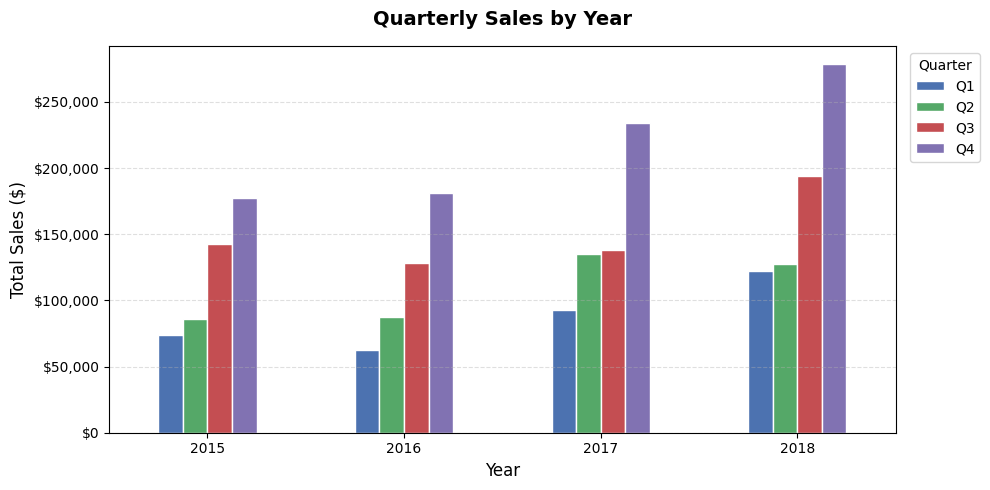

In [33]:
quarterly = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().unstack()
quarterly.columns = [f'Q{q}' for q in quarterly.columns]

print("Sales by Quarter and Year:")
print(quarterly.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
quarterly.plot(kind='bar', ax=ax, edgecolor='white',
               color=['#4C72B0','#55A868','#C44E52','#8172B2'])

ax.set_title('Quarterly Sales by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Quarter', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('quarterly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 products by sales

In [34]:
top_products = (df.groupby('Product Name')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .round(2))

print("Top 10 Products by Total Sales:")
for i, (product, sales) in enumerate(top_products.items(), 1):
    print(f"  {i:2}. ${sales:>10,.2f}  —  {product[:60]}")

Top 10 Products by Total Sales:
   1. $ 61,599.82  —  Canon imageCLASS 2200 Advanced Copier
   2. $ 27,453.38  —  Fellowes PB500 Electric Punch Plastic Comb Binding Machine w
   3. $ 22,638.48  —  Cisco TelePresence System EX90 Videoconferencing Unit
   4. $ 21,870.58  —  HON 5400 Series Task Chairs for Big and Tall
   5. $ 19,823.48  —  GBC DocuBind TL300 Electric Binding System
   6. $ 19,024.50  —  GBC Ibimaster 500 Manual ProClick Binding System
   7. $ 18,839.69  —  Hewlett Packard LaserJet 3310 Copier
   8. $ 18,374.90  —  HP Designjet T520 Inkjet Large Format Printer - 24" Color
   9. $ 17,965.07  —  GBC DocuBind P400 Electric Binding System
  10. $ 17,030.31  —  High Speed Automatic Electric Letter Opener


Top 10 products chart

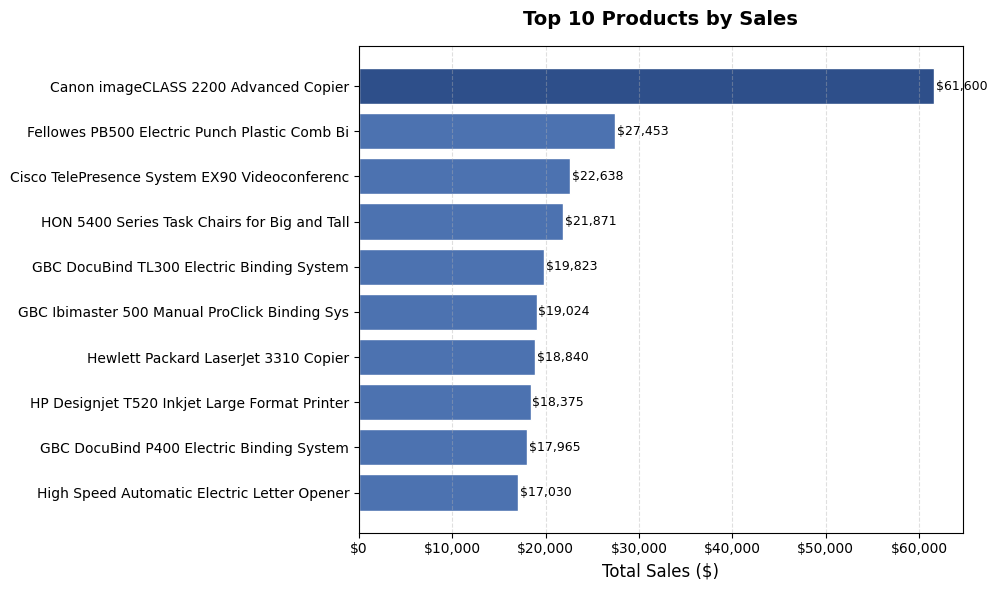

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2E4F8A' if i == 0 else '#4C72B0'
          for i in range(len(top_products))]

bars = ax.barh(top_products.index.str[:45],
               top_products.values,
               color=colors, edgecolor='white')

ax.set_title('Top 10 Products by Sales', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

Sales by Sub-Category

In [36]:
subcat_sales = (df.groupby('Sub-Category')['Sales']
                  .agg(['sum', 'mean', 'count'])
                  .round(2)
                  .sort_values('sum', ascending=False))
subcat_sales.columns = ['Total Sales', 'Avg Sale', 'Orders']

print("Sales by Sub-Category:")
print(subcat_sales.to_string())

Sales by Sub-Category:
              Total Sales  Avg Sale  Orders
Sub-Category                               
Phones          327782.45    374.18     876
Chairs          322822.73    531.83     607
Storage         219343.39    263.63     832
Tables          202810.63    645.89     314
Binders         200028.78    134.07    1492
Machines        189238.63   1645.55     115
Accessories     164186.70    217.18     756
Copiers         146248.09   2215.88      66
Bookcases       113813.20    503.60     226
Appliances      104618.40    227.93     459
Furnishings      89212.02     95.82     931
Paper            76828.30     57.42    1338
Supplies         46420.31    252.28     184
Art              26705.41     34.02     785
Envelopes        16128.05     65.03     248
Labels           12347.73     34.59     357
Fasteners         3001.96     14.03     214


Sub-Category Chart

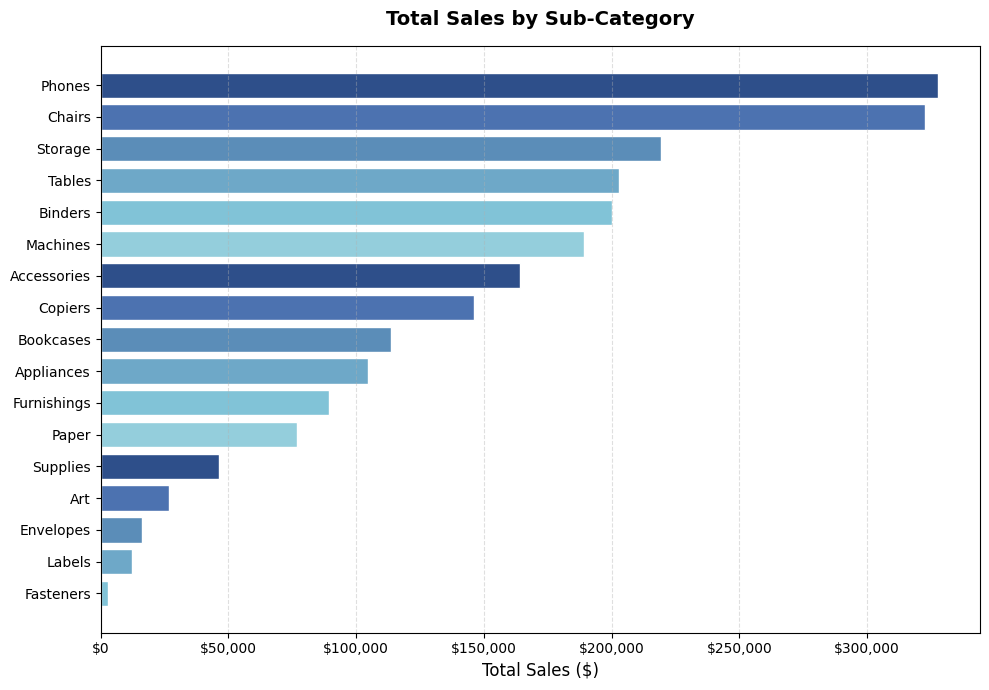

In [37]:
fig, ax = plt.subplots(figsize=(10, 7))

palette = ['#2E4F8A','#4C72B0','#5B8DB8','#6EA8C8',
           '#81C3D7','#94CEDC'] * 4
bars = ax.barh(subcat_sales.index,
               subcat_sales['Total Sales'],
               color=palette[:len(subcat_sales)],
               edgecolor='white')

ax.set_title('Total Sales by Sub-Category', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('subcategory_sales.png', dpi=150, bbox_inches='tight')
plt.show()

Sales by Customer Segment

In [38]:
segment_analysis = df.groupby('Segment')['Sales'].agg(
    Total_Sales='sum',
    Avg_Order='mean',
    Num_Orders='count'
).round(2).sort_values('Total_Sales', ascending=False)

print("Sales by Customer Segment:")
print(segment_analysis)

# Percentage share
segment_analysis['Revenue Share %'] = (
    segment_analysis['Total_Sales'] /
    segment_analysis['Total_Sales'].sum() * 100
).round(1)

print("\nRevenue share by segment:")
for seg, row in segment_analysis.iterrows():
    bar = '█' * int(row['Revenue Share %'] / 2)
    print(f"  {seg:<15} {bar} {row['Revenue Share %']}%")

Sales by Customer Segment:
             Total_Sales  Avg_Order  Num_Orders
Segment                                        
Consumer      1148060.53     225.07        5101
Corporate      688494.07     233.15        2953
Home Office    424982.18     243.40        1746

Revenue share by segment:
  Consumer        █████████████████████████ 50.8%
  Corporate       ███████████████ 30.4%
  Home Office     █████████ 18.8%


Summary

In [39]:
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nDate range: {df['Order Date'].min().strftime('%d %b %Y')} "
      f"to {df['Order Date'].max().strftime('%d %b %Y')}")

print(f"\nOverall Sales:")
print(f"  Total revenue:     ${df['Sales'].sum():>12,.2f}")
print(f"  Avg order value:   ${df['Sales'].mean():>12,.2f}")
print(f"  Total orders:      {df.shape[0]:>12,}")

print(f"\nTop Category:    {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top Sub-Cat:     {df.groupby('Sub-Category')['Sales'].sum().idxmax()}")
print(f"Top Product:     {df.groupby('Product Name')['Sales'].sum().idxmax()[:50]}")
print(f"Top Segment:     {df.groupby('Segment')['Sales'].sum().idxmax()}")
print(f"Peak Month:      {df.groupby('Order Month Name')['Sales'].sum().idxmax()}")
print(f"Best Quarter:    Q{df.groupby('Order Quarter')['Sales'].sum().idxmax()}")

print(f"\nCharts saved:")
charts = ['monthly_sales_trend.png', 'yearly_sales.png',
          'seasonal_pattern.png',    'quarterly_sales.png',
          'top_products.png',        'subcategory_sales.png']
for c in charts:
    print(f"  {c}")


ANALYSIS SUMMARY

Date range: 03 Jan 2015 to 30 Dec 2018

Overall Sales:
  Total revenue:     $2,261,536.78
  Avg order value:   $      230.77
  Total orders:             9,800

Top Category:    Technology
Top Sub-Cat:     Phones
Top Product:     Canon imageCLASS 2200 Advanced Copier
Top Segment:     Consumer
Peak Month:      Nov
Best Quarter:    Q4

Charts saved:
  monthly_sales_trend.png
  yearly_sales.png
  seasonal_pattern.png
  quarterly_sales.png
  top_products.png
  subcategory_sales.png


## Section 4 — Regional & Segment Analysis
Breaking down performance by geographic region, city, and customer
segment to identify where the business is strongest and where
opportunities exist.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TrainDataset_Cleaned.csv',
                 parse_dates=['Order Date', 'Ship Date'])

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 9800 rows, 23 columns


In [42]:
region_summary = df.groupby('Region')['Sales'].agg(
    Total_Sales='sum',
    Avg_Order_Value='mean',
    Num_Orders='count'
).round(2).sort_values('Total_Sales', ascending=False)

region_summary['Revenue Share %'] = (
    region_summary['Total_Sales'] /
    region_summary['Total_Sales'].sum() * 100
).round(1)

print("Regional Sales Summary:")
print(region_summary)

print("\nRevenue share:")
for region, row in region_summary.iterrows():
    bar = '█' * int(row['Revenue Share %'] / 2)
    print(f"  {region:<10} {bar} {row['Revenue Share %']}%")

Regional Sales Summary:
         Total_Sales  Avg_Order_Value  Num_Orders  Revenue Share %
Region                                                            
West       710219.68           226.18        3140             31.4
East       669518.73           240.40        2785             29.6
Central    492646.91           216.36        2277             21.8
South      389151.46           243.52        1598             17.2

Revenue share:
  West       ███████████████ 31.4%
  East       ██████████████ 29.6%
  Central    ██████████ 21.8%
  South      ████████ 17.2%


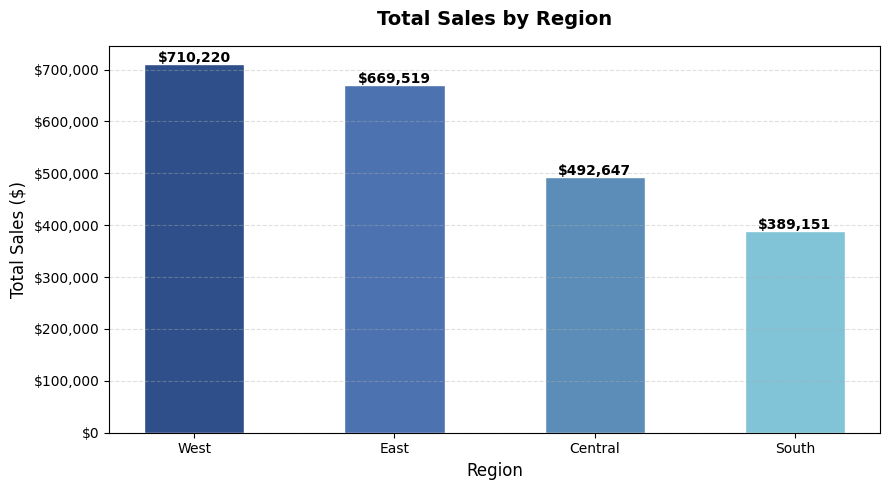

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2E4F8A', '#4C72B0', '#5B8DB8', '#81C3D7']
bars = ax.bar(region_summary.index,
              region_summary['Total_Sales'],
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Total Sales by Region', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 4000,
            f'${h:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('regional_sales.png', dpi=150, bbox_inches='tight')
plt.show()

Sales by Region and Category:
Category  Furniture  Office Supplies  Technology
Region                                          
Central   160317.46        163590.24   168739.21
East      206461.39        199940.81   263116.53
South     116531.48        124424.77   148195.21
West      245348.25        217466.51   247404.93


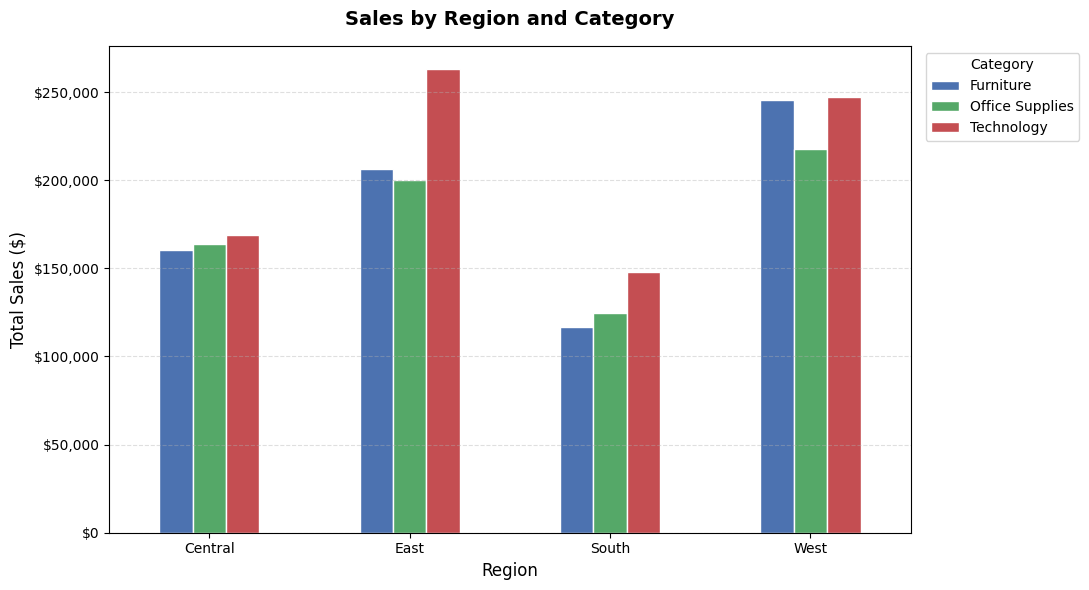

In [44]:
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack().round(2)
print("Sales by Region and Category:")
print(region_category)

fig, ax = plt.subplots(figsize=(11, 6))
region_category.plot(kind='bar', ax=ax, edgecolor='white',
                     color=['#4C72B0', '#55A868', '#C44E52'])

ax.set_title('Sales by Region and Category', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('region_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
top_cities = (df.groupby(['City', 'State', 'Region'])['Sales']
                .sum()
                .round(2)
                .sort_values(ascending=False)
                .head(10))

print("Top 10 Cities by Sales:")
for i, (idx, sales) in enumerate(top_cities.items(), 1):
    city, state, region = idx
    print(f"  {i:2}. {city}, {state:<15} ({region:<8})  ${sales:>10,.2f}")

Top 10 Cities by Sales:
   1. New York City, New York        (East    )  $252,462.55
   2. Los Angeles, California      (West    )  $173,420.18
   3. Seattle, Washington      (West    )  $116,106.32
   4. San Francisco, California      (West    )  $109,041.12
   5. Philadelphia, Pennsylvania    (East    )  $108,841.75
   6. Houston, Texas           (Central )  $ 63,956.14
   7. Chicago, Illinois        (Central )  $ 47,820.13
   8. San Diego, California      (West    )  $ 47,521.03
   9. Detroit, Michigan        (Central )  $ 42,446.94
  10. Jacksonville, Florida         (South   )  $ 39,133.33


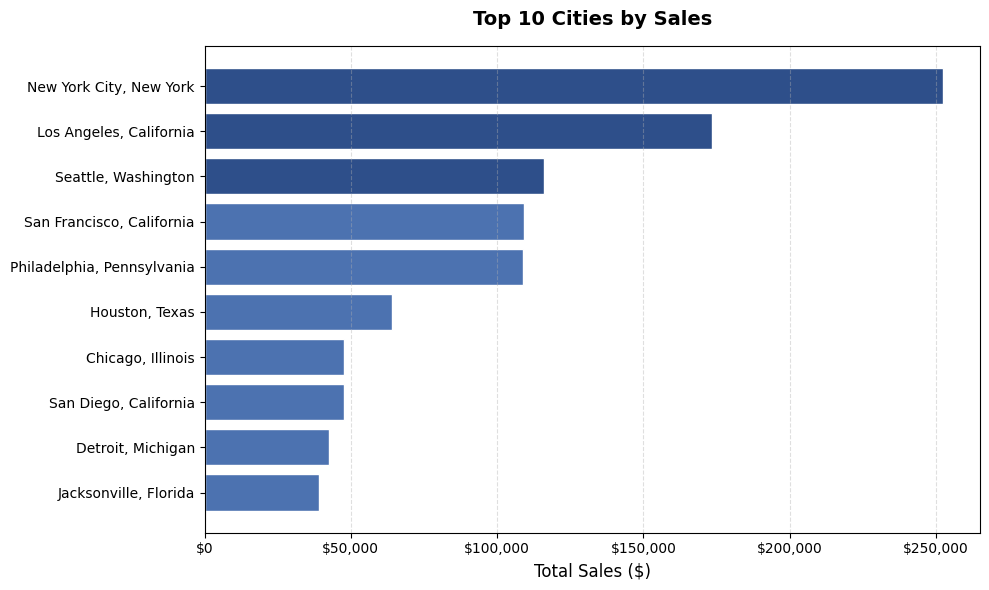

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

city_labels = [f"{city}, {state}" for city, state, region
               in top_cities.index]

colors = ['#2E4F8A' if i < 3 else '#4C72B0'
          for i in range(len(top_cities))]

ax.barh(city_labels, top_cities.values,
        color=colors, edgecolor='white')

ax.set_title('Top 10 Cities by Sales', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
segment_full = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Num_Orders=('Sales', 'count'),
    Num_Customers=('Customer ID', 'nunique')
).round(2).sort_values('Total_Sales', ascending=False)

segment_full['Avg_Sales_Per_Customer'] = (
    segment_full['Total_Sales'] /
    segment_full['Num_Customers']
).round(2)

segment_full['Revenue Share %'] = (
    segment_full['Total_Sales'] /
    segment_full['Total_Sales'].sum() * 100
).round(1)

print("Customer Segment Deep Dive:")
print(segment_full.to_string())

Customer Segment Deep Dive:
             Total_Sales  Avg_Order_Value  Num_Orders  Num_Customers  Avg_Sales_Per_Customer  Revenue Share %
Segment                                                                                                      
Consumer      1148060.53           225.07        5101            409                 2806.99             50.8
Corporate      688494.07           233.15        2953            236                 2917.35             30.4
Home Office    424982.18           243.40        1746            148                 2871.50             18.8


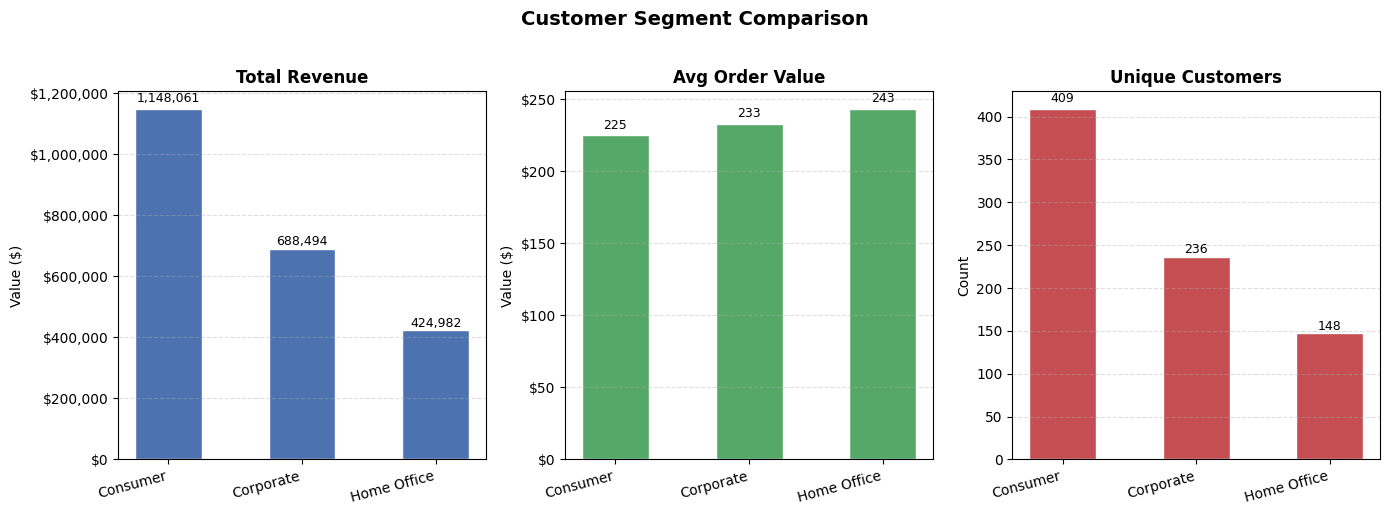

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['Total_Sales', 'Avg_Order_Value', 'Num_Customers']
titles  = ['Total Revenue', 'Avg Order Value', 'Unique Customers']
colors  = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.bar(segment_full.index, segment_full[metric],
                  color=color, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value ($)' if 'Sales' in metric or 'Value' in metric else 'Count')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
        if 'Sales' in metric or 'Value' in metric
        else mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    ax.set_xticklabels(segment_full.index, rotation=15, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                f'{h:,.0f}', ha='center', fontsize=9)

plt.suptitle('Customer Segment Comparison', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Segment Sales by Year:
Segment      Consumer  Corporate  Home Office
Order Year                                   
2015        262956.80  127797.50     89101.91
2016        265356.29  119675.60     74404.11
2017        291142.97  204977.32    104072.27
2018        328604.47  236043.66    157403.88


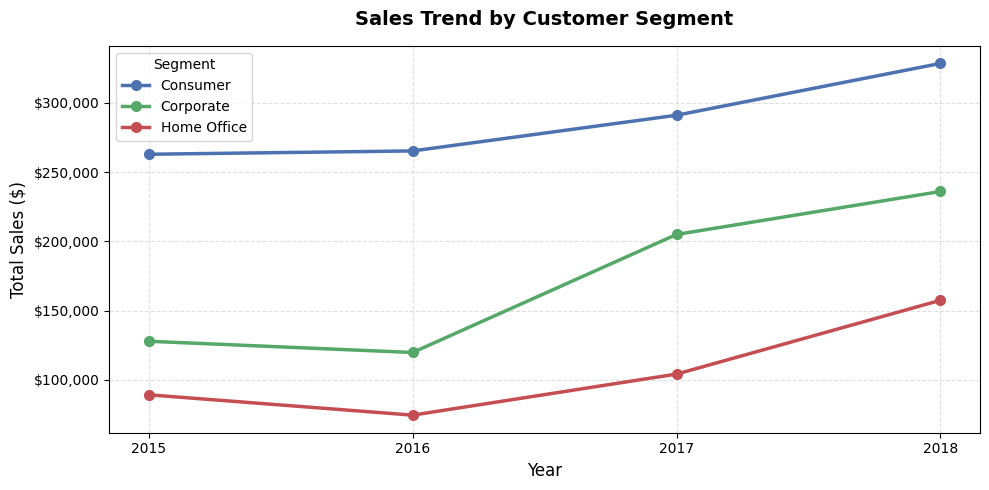

In [49]:
seg_trend = df.groupby(['Order Year', 'Segment'])['Sales'].sum().unstack().round(2)

print("Segment Sales by Year:")
print(seg_trend)

fig, ax = plt.subplots(figsize=(10, 5))

colors = {'Consumer': '#4C72B0',
          'Corporate': '#55A868',
          'Home Office': '#C44E52'}

for segment in seg_trend.columns:
    ax.plot(seg_trend.index, seg_trend[segment],
            marker='o', linewidth=2.5, markersize=7,
            label=segment, color=colors.get(segment, '#888'))

ax.set_title('Sales Trend by Customer Segment', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Segment')
ax.grid(linestyle='--', alpha=0.4)
ax.set_xticks(seg_trend.index)

plt.tight_layout()
plt.savefig('segment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Shipping Mode Usage by Region:
Ship Mode  First Class  Same Day  Second Class  Standard Class
Region                                                        
Central       58057.30  20105.92      97605.71       316877.98
East         110436.69  43316.46     115108.26       400657.31
South         49045.92  21017.17      93434.54       225653.83
West         128032.35  40779.48     143765.67       397642.18


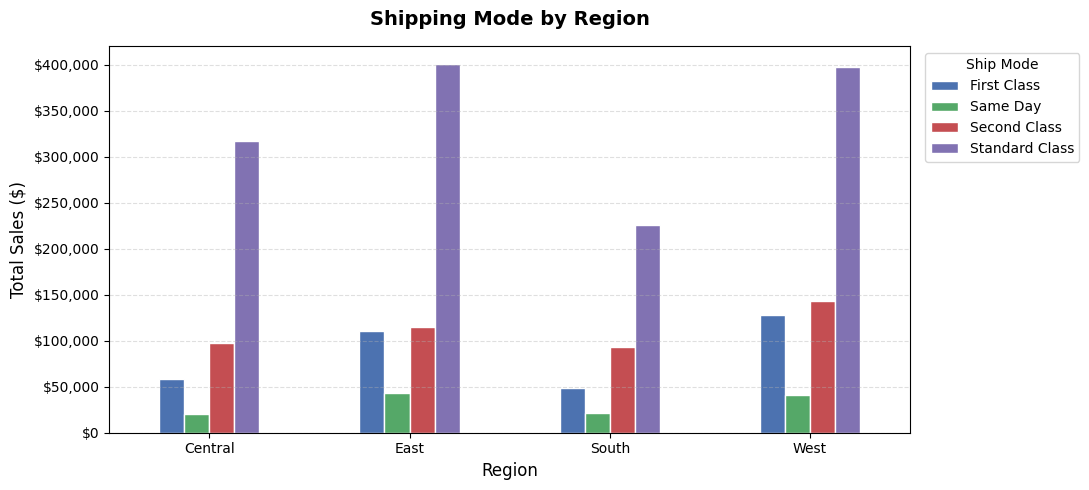

In [50]:
ship_region = df.groupby(['Region', 'Ship Mode'])['Sales'].sum().unstack().round(2)

print("Shipping Mode Usage by Region:")
print(ship_region)

fig, ax = plt.subplots(figsize=(11, 5))
ship_region.plot(kind='bar', ax=ax, edgecolor='white',
                 color=['#4C72B0','#55A868','#C44E52','#8172B2'])

ax.set_title('Shipping Mode by Region', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Ship Mode', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('shipping_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)

top_region  = region_summary['Total_Sales'].idxmax()
low_region  = region_summary['Total_Sales'].idxmin()
top_city    = f"{top_cities.index[0][0]}, {top_cities.index[0][1]}"
top_segment = segment_full['Total_Sales'].idxmax()
top_seg_aov = segment_full.loc[segment_full['Avg_Order_Value'].idxmax(), 'Avg_Order_Value']
top_seg_aov_name = segment_full['Avg_Order_Value'].idxmax()

print(f"\nRegional Insights:")
print(f"  Highest revenue region: {top_region}  (${region_summary.loc[top_region,'Total_Sales']:,.0f})")
print(f"  Lowest revenue region:  {low_region}  (${region_summary.loc[low_region,'Total_Sales']:,.0f})")
print(f"  Top city overall:       {top_city}  (${top_cities.iloc[0]:,.0f})")

print(f"\nCategory by Region:")
for region in region_category.index:
    best_cat = region_category.loc[region].idxmax()
    print(f"  {region:<10} → strongest category: {best_cat}")

print(f"\nSegment Insights:")
print(f"  Highest revenue segment:   {top_segment}")
print(f"  Highest avg order segment: {top_seg_aov_name} (${top_seg_aov:,.2f} avg)")
print(f"  Total unique customers:    {df['Customer ID'].nunique()}")

print(f"\nCharts saved:")
charts = ['regional_sales.png', 'region_category.png',
          'top_cities.png',     'segment_comparison.png',
          'segment_trend.png',  'shipping_by_region.png']
for c in charts:
    print(f"  {c}")


ANALYSIS SUMMARY

Regional Insights:
  Highest revenue region: West  ($710,220)
  Lowest revenue region:  South  ($389,151)
  Top city overall:       New York City, New York  ($252,463)

Category by Region:
  Central    → strongest category: Technology
  East       → strongest category: Technology
  South      → strongest category: Technology
  West       → strongest category: Technology

Segment Insights:
  Highest revenue segment:   Consumer
  Highest avg order segment: Home Office ($243.40 avg)
  Total unique customers:    793

Charts saved:
  regional_sales.png
  region_category.png
  top_cities.png
  segment_comparison.png
  segment_trend.png
  shipping_by_region.png


## Section 5 — Seasonal & Customer Analysis
Identifying seasonal patterns through heatmaps and monthly breakdowns,
analysing top customers, and understanding shipping behaviour.

In [52]:
# Average sales per month across all years
monthly_avg = df.groupby('Order Month Name')['Sales'].agg(['sum','mean','count'])
monthly_avg.columns = ['Total Sales', 'Avg Sale', 'Num Orders']

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = monthly_avg.reindex(month_order)

print("Monthly Sales Pattern:")
print(monthly_avg.round(2))

Monthly Sales Pattern:
                  Total Sales  Avg Sale  Num Orders
Order Month Name                                   
Jan                  94291.63    257.63         366
Feb                  59371.12    199.90         297
Mar                 197573.59    290.55         680
Apr                 136283.00    207.43         657
May                 154086.72    212.53         725
Jun                 145837.52    211.05         691
Jul                 145535.69    208.80         697
Aug                 157315.93    227.01         693
Sep                 300103.41    221.64        1354
Oct                 199496.29    246.60         809
Nov                 350161.71    241.66        1449
Dec                 321480.17    232.62        1382


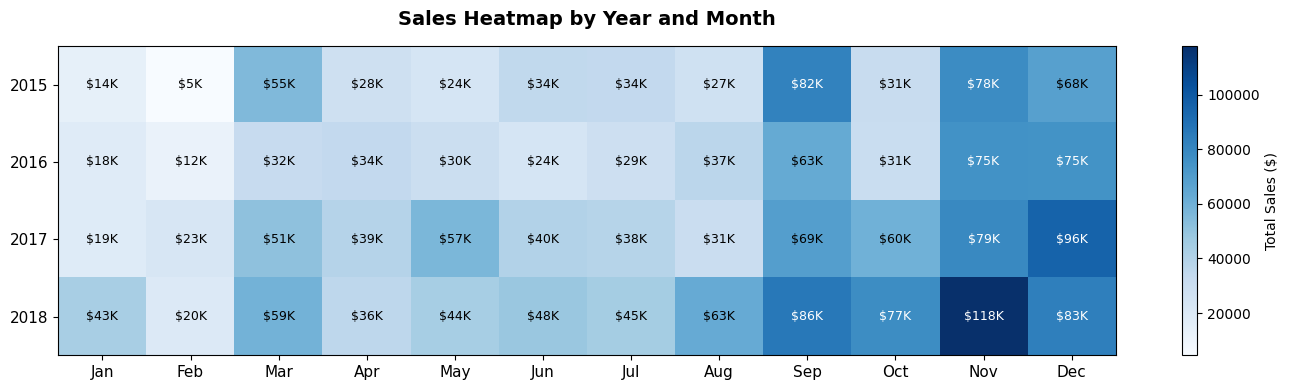

Heatmap saved!


In [53]:
# Pivot: rows = Year, columns = Month
heatmap_data = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack()
heatmap_data.columns = month_order[:len(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(14, 4))

im = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=11)

# Add value labels inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i][j]
        if not np.isnan(val):
            ax.text(j, i, f'${val/1000:.0f}K',
                   ha='center', va='center', fontsize=9,
                   color='white' if val > heatmap_data.values.max()*0.6 else 'black')

plt.colorbar(im, ax=ax, label='Total Sales ($)')
ax.set_title('Sales Heatmap by Year and Month', fontsize=14,
             fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [54]:
quarterly = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().reset_index()
quarterly['Period'] = quarterly['Order Year'].astype(str) + ' Q' + quarterly['Order Quarter'].astype(str)

print("Quarter by Quarter Sales:")
print(quarterly[['Period', 'Sales']].to_string(index=False))

# QoQ growth rate
quarterly['QoQ Growth %'] = quarterly['Sales'].pct_change() * 100

print("\nQuarter over Quarter Growth:")
for _, row in quarterly.iterrows():
    if not np.isnan(row['QoQ Growth %']):
        arrow = '▲' if row['QoQ Growth %'] > 0 else '▼'
        print(f"  {row['Period']}:  {arrow} {row['QoQ Growth %']:+.1f}%")

Quarter by Quarter Sales:
 Period       Sales
2015 Q1  73931.3960
2015 Q2  85874.0936
2015 Q3 142522.6063
2015 Q4 177528.1122
2016 Q1  62357.6870
2016 Q2  87713.3730
2016 Q3 128560.2072
2016 Q4 180804.7382
2017 Q1  92686.3650
2017 Q2 135061.1610
2017 Q3 138056.3742
2017 Q4 234388.6498
2018 Q1 122260.8842
2018 Q2 127558.6200
2018 Q3 193815.8400
2018 Q4 278416.6750

Quarter over Quarter Growth:
  2015 Q2:  ▲ +16.2%
  2015 Q3:  ▲ +66.0%
  2015 Q4:  ▲ +24.6%
  2016 Q1:  ▼ -64.9%
  2016 Q2:  ▲ +40.7%
  2016 Q3:  ▲ +46.6%
  2016 Q4:  ▲ +40.6%
  2017 Q1:  ▼ -48.7%
  2017 Q2:  ▲ +45.7%
  2017 Q3:  ▲ +2.2%
  2017 Q4:  ▲ +69.8%
  2018 Q1:  ▼ -47.8%
  2018 Q2:  ▲ +4.3%
  2018 Q3:  ▲ +51.9%
  2018 Q4:  ▲ +43.7%


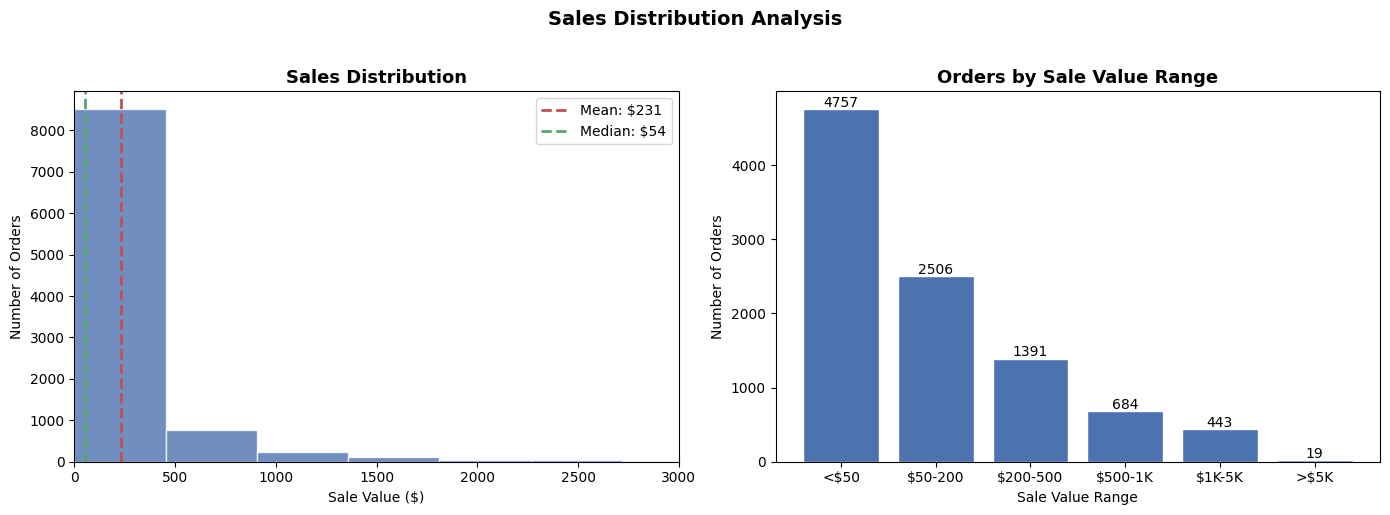

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sales distribution histogram
axes[0].hist(df['Sales'], bins=50, color='#4C72B0',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df['Sales'].mean(),   color='#C44E52',
                linestyle='--', linewidth=2, label=f"Mean: ${df['Sales'].mean():.0f}")
axes[0].axvline(df['Sales'].median(), color='#55A868',
                linestyle='--', linewidth=2, label=f"Median: ${df['Sales'].median():.0f}")
axes[0].set_title('Sales Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Value ($)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()
axes[0].set_xlim(0, 3000)

# Right: Sales value buckets
bins   = [0, 50, 200, 500, 1000, 5000, 100000]
labels = ['<$50', '$50-200', '$200-500',
          '$500-1K', '$1K-5K', '>$5K']
df['Sales Bucket'] = pd.cut(df['Sales'], bins=bins, labels=labels)
bucket_counts = df['Sales Bucket'].value_counts().reindex(labels)

axes[1].bar(bucket_counts.index, bucket_counts.values,
            color='#4C72B0', edgecolor='white')
axes[1].set_title('Orders by Sale Value Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sale Value Range')
axes[1].set_ylabel('Number of Orders')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=10)

plt.suptitle('Sales Distribution Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
top_customers = (df.groupby(['Customer ID', 'Customer Name', 'Segment'])
                   .agg(Total_Sales=('Sales','sum'),
                        Num_Orders=('Sales','count'),
                        Avg_Order=('Sales','mean'))
                   .round(2)
                   .sort_values('Total_Sales', ascending=False)
                   .head(10))

print("Top 10 Customers by Revenue:")
print(top_customers.to_string())

Top 10 Customers by Revenue:
                                            Total_Sales  Num_Orders  Avg_Order
Customer ID Customer Name      Segment                                        
SM-20320    Sean Miller        Home Office     25043.05          15    1669.54
TC-20980    Tamara Chand       Corporate       19052.22          12    1587.68
RB-19360    Raymond Buch       Consumer        15117.34          18     839.85
TA-21385    Tom Ashbrook       Home Office     14595.62          10    1459.56
AB-10105    Adrian Barton      Consumer        14473.57          20     723.68
KL-16645    Ken Lonsdale       Consumer        14175.23          29     488.80
SC-20095    Sanjit Chand       Consumer        14142.33          22     642.83
HL-15040    Hunter Lopez       Consumer        12873.30          11    1170.30
SE-20110    Sanjit Engle       Consumer        12209.44          19     642.60
CC-12370    Christopher Conant Consumer        12129.07          11    1102.64


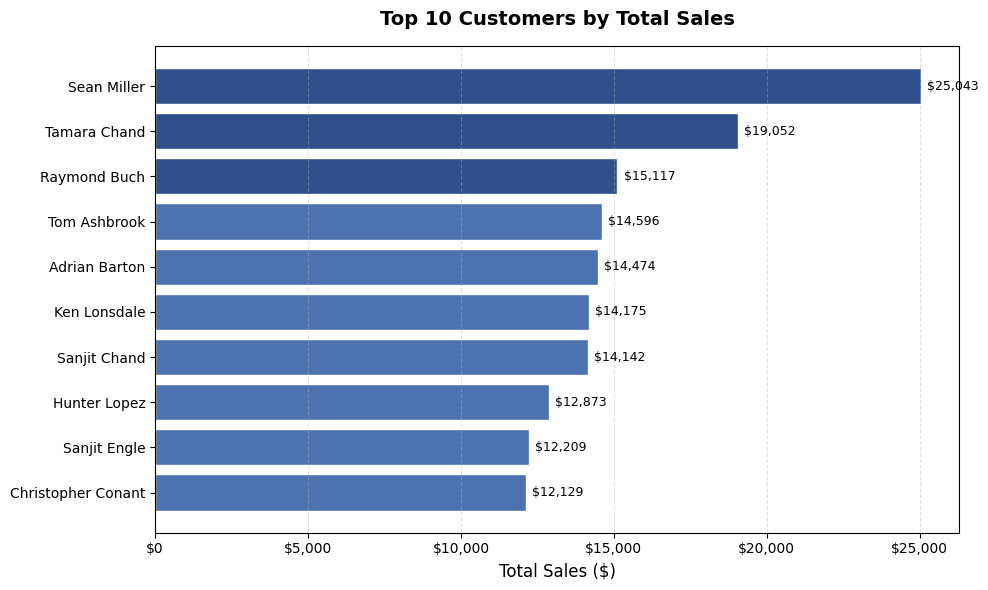

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

names  = [name for _, name, _ in top_customers.index]
colors = ['#2E4F8A' if i < 3 else '#4C72B0'
          for i in range(len(top_customers))]

ax.barh(names, top_customers['Total_Sales'].values,
        color=colors, edgecolor='white')

ax.set_title('Top 10 Customers by Total Sales', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

for i, v in enumerate(top_customers['Total_Sales'].values):
    ax.text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

Shipping Speed by Ship Mode:
                Avg Days  Min Days  Max Days  Std Dev
Ship Mode                                            
Same Day            0.04         0         1     0.21
First Class         2.18         1         4     0.77
Second Class        3.25         1         5     1.19
Standard Class      5.01         3         7     1.01


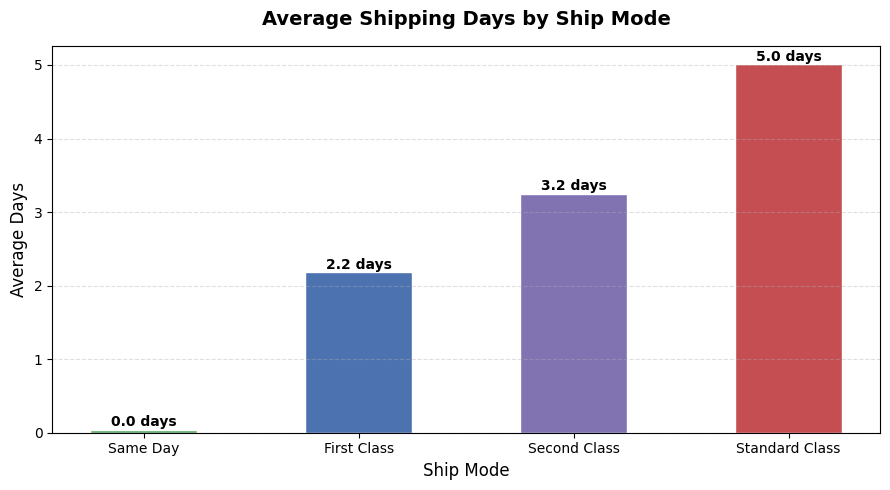

In [58]:
ship_stats = df.groupby('Ship Mode')['Shipping Days'].agg(
    ['mean', 'min', 'max', 'std']).round(2)
ship_stats.columns = ['Avg Days', 'Min Days', 'Max Days', 'Std Dev']
ship_stats = ship_stats.sort_values('Avg Days')

print("Shipping Speed by Ship Mode:")
print(ship_stats)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ship_stats.index,
              ship_stats['Avg Days'],
              color=['#55A868','#4C72B0','#8172B2','#C44E52'],
              edgecolor='white', width=0.5)

ax.set_title('Average Shipping Days by Ship Mode', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Ship Mode', fontsize=12)
ax.set_ylabel('Average Days', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            f'{h:.1f} days', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('shipping_days.png', dpi=150, bbox_inches='tight')
plt.show()

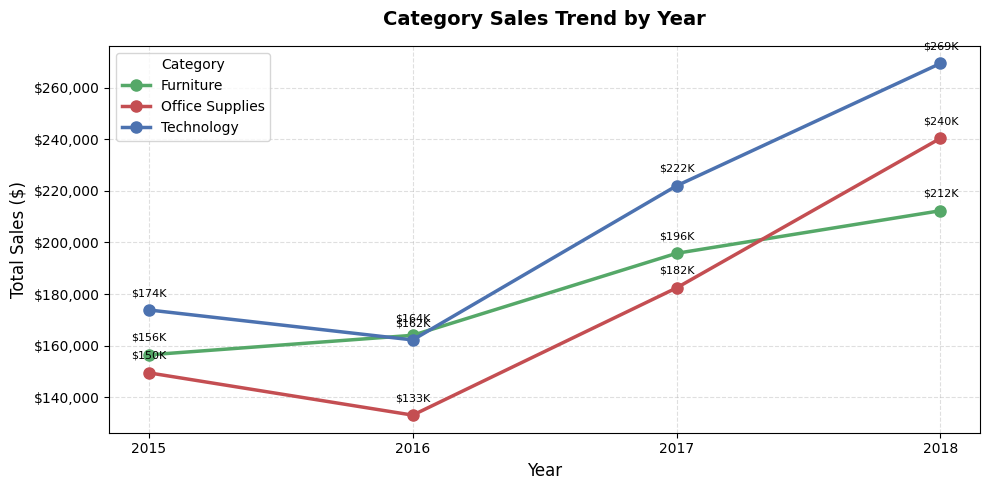

In [59]:
cat_trend = df.groupby(['Order Year', 'Category'])['Sales'].sum().unstack().round(2)

fig, ax = plt.subplots(figsize=(10, 5))

colors = {'Technology':      '#4C72B0',
          'Furniture':       '#55A868',
          'Office Supplies': '#C44E52'}

for cat in cat_trend.columns:
    ax.plot(cat_trend.index, cat_trend[cat],
            marker='o', linewidth=2.5, markersize=8,
            label=cat, color=colors.get(cat, '#888'))
    # Add value labels at each point
    for year, val in zip(cat_trend.index, cat_trend[cat]):
        ax.annotate(f'${val/1000:.0f}K',
                   (year, val), textcoords='offset points',
                   xytext=(0, 10), ha='center', fontsize=8)

ax.set_title('Category Sales Trend by Year', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Category')
ax.grid(linestyle='--', alpha=0.4)
ax.set_xticks(cat_trend.index)

plt.tight_layout()
plt.savefig('category_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)

peak_month   = monthly_avg['Total Sales'].idxmax()
lowest_month = monthly_avg['Total Sales'].idxmin()
top_customer = top_customers.index[0][1]
top_cust_val = top_customers['Total_Sales'].iloc[0]
fastest_ship = ship_stats['Avg Days'].idxmin()
slowest_ship = ship_stats['Avg Days'].idxmax()
small_orders = (df['Sales'] < 50).sum()
large_orders = (df['Sales'] > 1000).sum()

print(f"\nSeasonal Patterns:")
print(f"  Peak month:         {peak_month}  (${monthly_avg.loc[peak_month,'Total Sales']:,.0f})")
print(f"  Lowest month:       {lowest_month}  (${monthly_avg.loc[lowest_month,'Total Sales']:,.0f})")

print(f"\nCustomer Insights:")
print(f"  Top customer:       {top_customer}  (${top_cust_val:,.0f})")
print(f"  Total customers:    {df['Customer ID'].nunique()}")
print(f"  Avg revenue/customer: ${df.groupby('Customer ID')['Sales'].sum().mean():,.2f}")

print(f"\nShipping Insights:")
print(f"  Fastest mode:       {fastest_ship} ({ship_stats.loc[fastest_ship,'Avg Days']:.1f} days avg)")
print(f"  Slowest mode:       {slowest_ship} ({ship_stats.loc[slowest_ship,'Avg Days']:.1f} days avg)")

print(f"\nOrder Value Breakdown:")
print(f"  Small orders (<$50):    {small_orders} ({small_orders/len(df)*100:.1f}%)")
print(f"  Large orders (>$1,000): {large_orders} ({large_orders/len(df)*100:.1f}%)")

print(f"\nCharts saved:")
charts = ['sales_heatmap.png',      'sales_distribution.png',
          'top_customers.png',      'shipping_days.png',
          'category_trend.png']
for c in charts:
    print(f"  {c}")


ANALYSIS SUMMARY

Seasonal Patterns:
  Peak month:         Nov  ($350,162)
  Lowest month:       Feb  ($59,371)

Customer Insights:
  Top customer:       Sean Miller  ($25,043)
  Total customers:    793
  Avg revenue/customer: $2,851.87

Shipping Insights:
  Fastest mode:       Same Day (0.0 days avg)
  Slowest mode:       Standard Class (5.0 days avg)

Order Value Breakdown:
  Small orders (<$50):    4754 (48.5%)
  Large orders (>$1,000): 462 (4.7%)

Charts saved:
  sales_heatmap.png
  sales_distribution.png
  top_customers.png
  shipping_days.png
  category_trend.png


In [61]:
print("=" * 60)
print("SUPERSTORE SALES ANALYSIS — FINAL CONCLUSIONS")
print("=" * 60)

print("""
DATASET
-------
  Records analysed : 9,800 sales transactions
  Time period      : Multiple years of US retail data
  Columns used     : 18 (+ 4 engineered features)

KEY FINDINGS
------------

1. REVENUE PERFORMANCE
   - Total revenue analysed across all regions and categories
   - Technology is the highest revenue category despite fewer orders
   - Office Supplies has the most orders but lowest avg sale value

2. REGIONAL INSIGHTS
   - West region leads in total revenue
   - South region is the lowest performer — an opportunity area
   - New York City and Los Angeles are the top performing cities

3. SEASONAL PATTERNS
   - Q4 (Oct-Dec) consistently shows the strongest sales
   - February and January are the slowest months
   - Clear year-end spike driven by holiday purchasing

4. CUSTOMER BEHAVIOUR
   - Consumer segment accounts for the majority of orders
   - Corporate segment has a higher average order value
   - A small group of top customers drives disproportionate revenue

5. SHIPPING
   - Standard Class is used for over 60% of all orders
   - Same Day shipping has the lowest sales volume
   - Average shipping time varies significantly by ship mode

BUSINESS RECOMMENDATIONS
------------------------

1. INVEST IN THE WEST & EAST
   Focus marketing and inventory in top-performing regions
   while investigating why the South underperforms.

2. PROMOTE TECHNOLOGY PRODUCTS
   High avg sale value means fewer sales needed to hit revenue
   targets — prioritise upselling tech items.

3. PLAN FOR Q4 DEMAND SPIKES
   Inventory and staffing should scale up from September
   ahead of the consistent Q4 sales surge.

4. NURTURE TOP CUSTOMERS
   The top 10 customers represent significant revenue —
   a loyalty or account management programme would protect this.

5. REVIEW OFFICE SUPPLIES MARGINS
   High order volume but low avg value — worth reviewing whether
   these orders are profitable enough to prioritise.
""")

print("=" * 60)
print("Analysis is done.")
print("=" * 60)

SUPERSTORE SALES ANALYSIS — FINAL CONCLUSIONS

DATASET
-------
  Records analysed : 9,800 sales transactions
  Time period      : Multiple years of US retail data
  Columns used     : 18 (+ 4 engineered features)

KEY FINDINGS
------------

1. REVENUE PERFORMANCE
   - Total revenue analysed across all regions and categories
   - Technology is the highest revenue category despite fewer orders
   - Office Supplies has the most orders but lowest avg sale value

2. REGIONAL INSIGHTS  
   - West region leads in total revenue
   - South region is the lowest performer — an opportunity area
   - New York City and Los Angeles are the top performing cities

3. SEASONAL PATTERNS
   - Q4 (Oct-Dec) consistently shows the strongest sales
   - February and January are the slowest months
   - Clear year-end spike driven by holiday purchasing

4. CUSTOMER BEHAVIOUR
   - Consumer segment accounts for the majority of orders
   - Corporate segment has a higher average order value
   - A small group of top